In [3]:
import pandas as pd
df = pd.read_csv(r'C:\Users\karun\Downloads\6- depressive-symptoms-across-us-population.csv')



C:\Users\karun\Downloads\anaconda\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [4]:

df["Total Frequency"] = (df["Nearly every day"] +df["More than half the days"] + df["Several days"])



In [5]:
print(df[["Entity","Total Frequency"]])


                     Entity  Total Frequency
0           Appetite change             25.2
1   Average across symptoms             23.7
2            Depressed mood             24.3
3  Difficulty concentrating             18.0
4          Loss of interest             26.1
5                Low energy             50.8
6           Low self-esteem             17.4
7     Psychomotor agitation             11.2
8            Sleep problems             36.6
9         Suicidal ideation              3.5


In [6]:
 
max_index = df["Total Frequency"].idxmax()

min_index = df["Total Frequency"].idxmin()

most_common = df.loc[max_index, "Entity"]
least_common = df.loc[min_index, "Entity"]

print("Most Common Symptom:", most_common)
print("Least Common Symptom:", least_common)


Most Common Symptom: Low energy
Least Common Symptom: Suicidal ideation


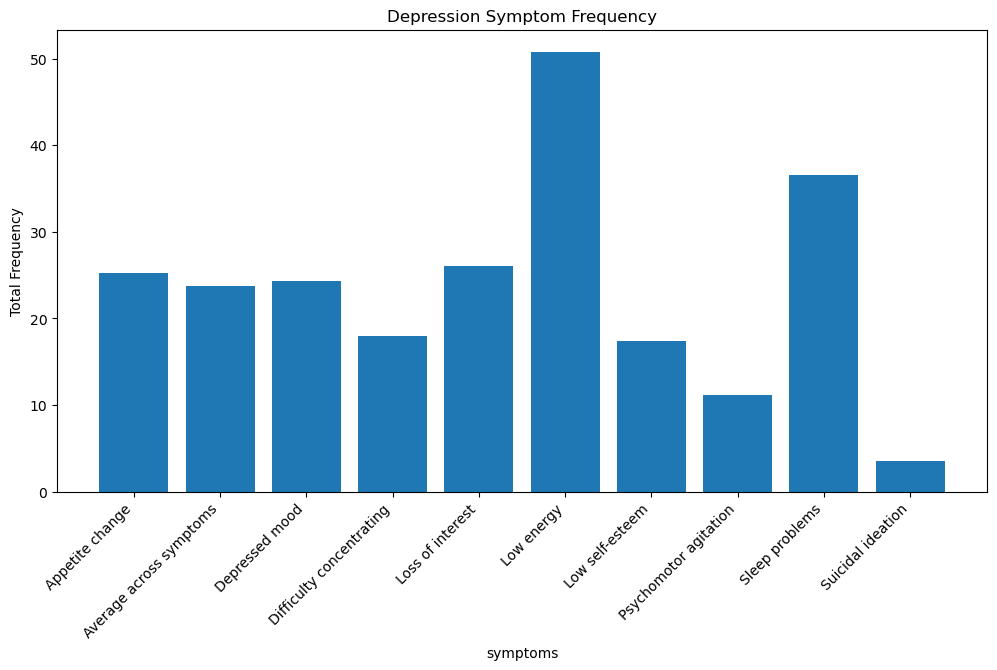

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.bar(df["Entity"], df["Total Frequency"])


plt.xticks(rotation=45, ha='right')

plt.xlabel("symptoms")
plt.ylabel("Total Frequency")
plt.title("Depression Symptom Frequency")


plt.tight_layout
plt.show()

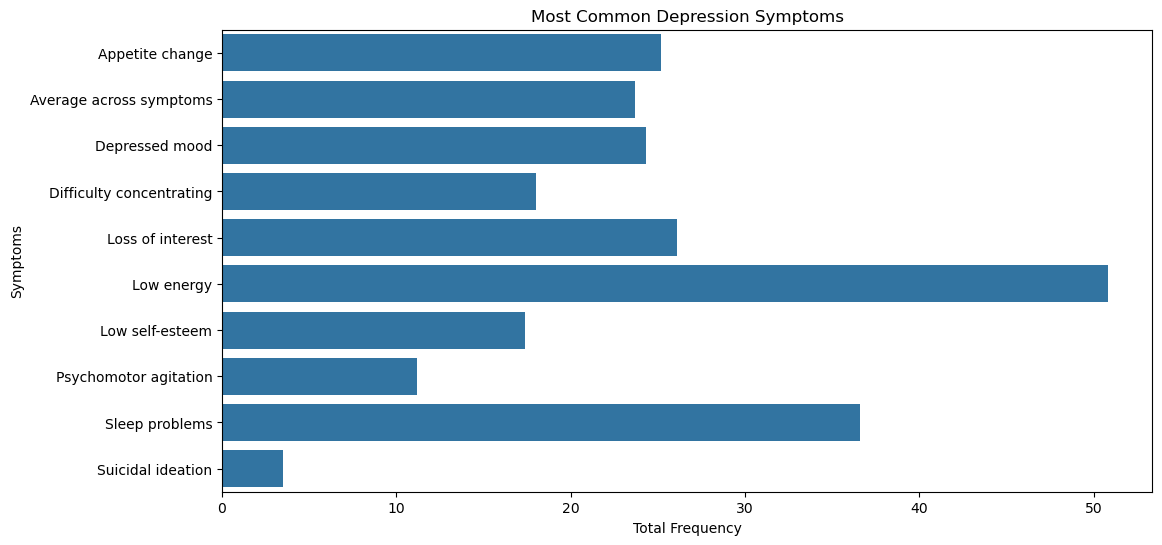

In [8]:
import seaborn as sns

plt.figure(figsize=(12,6))

sns.barplot(
    x="Total Frequency",
    y="Entity",
    data=df
)

plt.title("Most Common Depression Symptoms")
plt.xlabel("Total Frequency")
plt.ylabel("Symptoms")

plt.show()

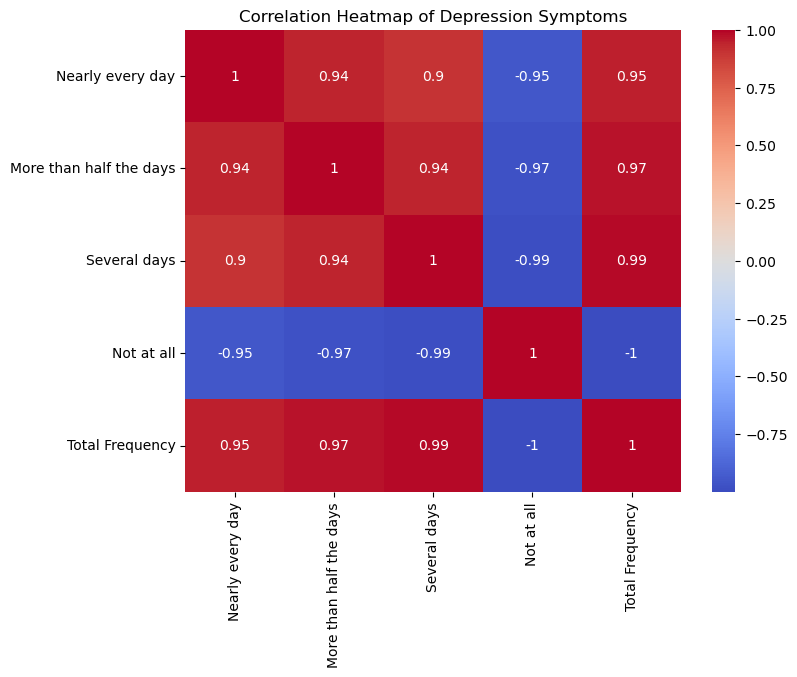

In [9]:
corr_data = df[
    [
        "Nearly every day",
        "More than half the days",
        "Several days",
        "Not at all",
        "Total Frequency"
    ]
]



correlation = corr_data.corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap of Depression Symptoms")

plt.show()


In [10]:
#Total symptom frequency has a strong positive correlation with severe symptom occurrence.

In [ ]:
#mental health over all the countries or regions

In [89]:
import pandas as pd

In [91]:
df=pd.read_csv(r'C:\Users\karun\Downloads\1- mental-illnesses-prevalence.csv')
               

In [92]:
df.head


<bound method NDFrame.head of            Entity Code  Year  \
0     Afghanistan  AFG  1990   
1     Afghanistan  AFG  1991   
2     Afghanistan  AFG  1992   
3     Afghanistan  AFG  1993   
4     Afghanistan  AFG  1994   
...           ...  ...   ...   
6415     Zimbabwe  ZWE  2015   
6416     Zimbabwe  ZWE  2016   
6417     Zimbabwe  ZWE  2017   
6418     Zimbabwe  ZWE  2018   
6419     Zimbabwe  ZWE  2019   

      Schizophrenia disorders (share of population) - Sex: Both - Age: Age-standardized  \
0                                              0.223206                                   
1                                              0.222454                                   
2                                              0.221751                                   
3                                              0.220987                                   
4                                              0.220183                                   
...                                    

In [93]:
df.info()

df.isnull().sum()
df.duplicated().sum()


<class 'pandas.DataFrame'>
RangeIndex: 6420 entries, 0 to 6419
Data columns (total 8 columns):
 #   Column                                                                             Non-Null Count  Dtype  
---  ------                                                                             --------------  -----  
 0   Entity                                                                             6420 non-null   str    
 1   Code                                                                               6150 non-null   str    
 2   Year                                                                               6420 non-null   int64  
 3   Schizophrenia disorders (share of population) - Sex: Both - Age: Age-standardized  6420 non-null   float64
 4   Depressive disorders (share of population) - Sex: Both - Age: Age-standardized     6420 non-null   float64
 5   Anxiety disorders (share of population) - Sex: Both - Age: Age-standardized        6420 non-null   float64
 6   Bipo

np.int64(0)

In [94]:
df = df.rename(columns={
    "Schizophrenia disorders (share of population) - Sex: Both - Age: Age-standardized": "Schizophrenia",
    
    "Depressive disorders (share of population) - Sex: Both - Age: Age-standardized": "Depression",

    "Anxiety disorders (share of population) - Sex: Both - Age: Age-standardized": "Anxiety",

    "Bipolar disorders (share of population) - Sex: Both - Age: Age-standardized": "Bipolar",

    "Eating disorders (share of population) - Sex: Both - Age: Age-standardized": "Eating"
})

In [95]:
df.head

<bound method NDFrame.head of            Entity Code  Year  Schizophrenia  Depression   Anxiety   Bipolar  \
0     Afghanistan  AFG  1990       0.223206    4.996118  4.713314  0.703023   
1     Afghanistan  AFG  1991       0.222454    4.989290  4.702100  0.702069   
2     Afghanistan  AFG  1992       0.221751    4.981346  4.683743  0.700792   
3     Afghanistan  AFG  1993       0.220987    4.976958  4.673549  0.700087   
4     Afghanistan  AFG  1994       0.220183    4.977782  4.670810  0.699898   
...           ...  ...   ...            ...         ...       ...       ...   
6415     Zimbabwe  ZWE  2015       0.201042    3.407624  3.184012  0.538596   
6416     Zimbabwe  ZWE  2016       0.201319    3.410755  3.187148  0.538593   
6417     Zimbabwe  ZWE  2017       0.201639    3.411965  3.188418  0.538589   
6418     Zimbabwe  ZWE  2018       0.201976    3.406929  3.172111  0.538585   
6419     Zimbabwe  ZWE  2019       0.202482    3.395476  3.137017  0.538580   

        Eating  
0   

In [96]:


disorders = [
    "Schizophrenia",
    "Depression",
    "Anxiety",
    "Bipolar",
    "Eating"
]

average_values = df[disorders].mean()

print(average_values)



Schizophrenia    0.266604
Depression       3.767036
Anxiety          4.101840
Bipolar          0.636968
Eating           0.195664
dtype: float64


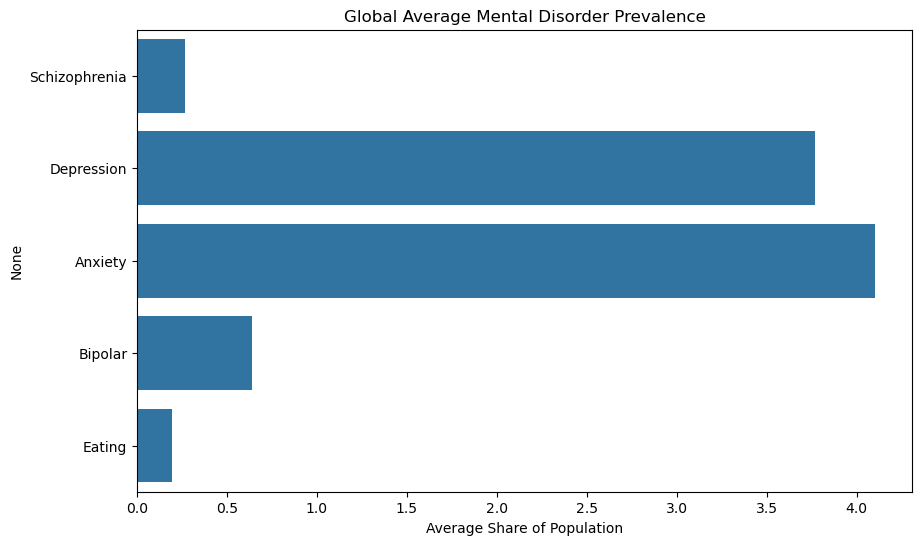

In [97]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.barplot(
    x=average_values.values,
    y=average_values.index
)

plt.title("Global Average Mental Disorder Prevalence")

plt.xlabel("Average Share of Population")

plt.show()

In [107]:
yearly_trend = df.groupby("Year")["Depression"].mean()

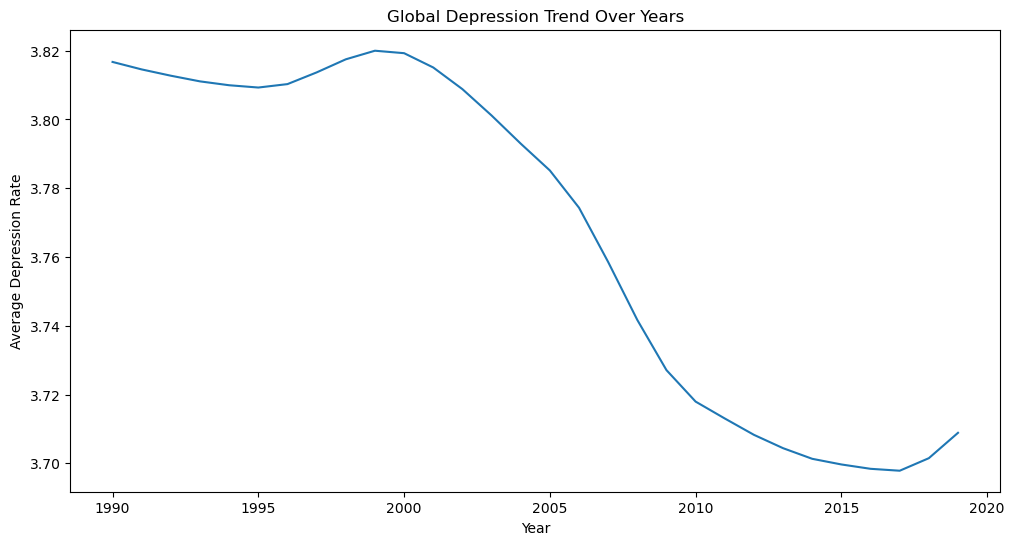

In [109]:
plt.figure(figsize=(12,6))

sns.lineplot(
    x=yearly_trend.index,
    y=yearly_trend.values
)

plt.title("Global Depression Trend Over Years")

plt.xlabel("Year")
plt.ylabel("Average Depression Rate")

plt.show()

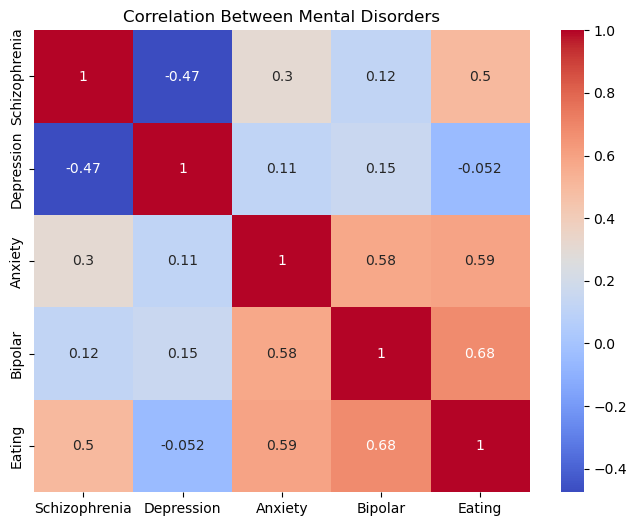

In [110]:
corr = df[disorders].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Between Mental Disorders")

plt.show()


In [111]:
import plotly.express as px


In [118]:
fig = px.choropleth(
    df,
    locations="Code",
    color="Depression",
    hover_name="Entity",
    animation_frame="Year",
    color_continuous_scale="Reds",
    title = "which countries or regions are more effected by mental disorders?"
)




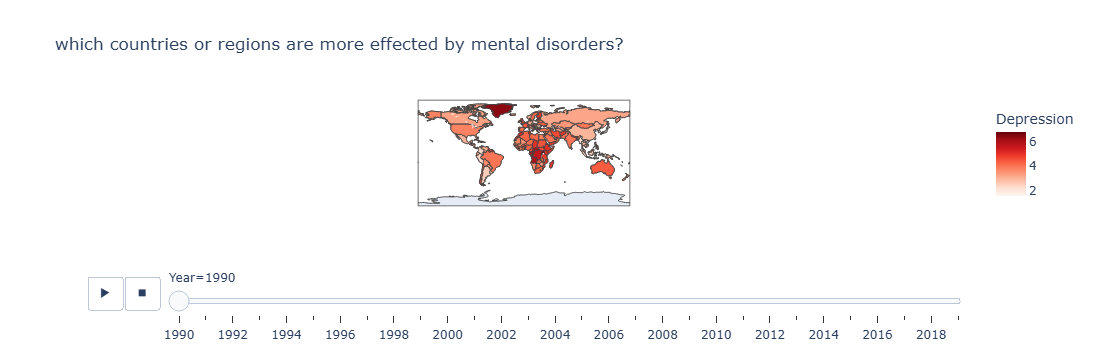

In [119]:

fig.show()


In [ ]:
### Choropleth Map Insights

The choropleth visualization revealed clear geographical differences in mental disorder prevalence across countries. Certain regions demonstrated consistently higher rates of depressive and anxiety disorders, suggesting potential socioeconomic, political, and healthcare-related influences on mental health outcomes.

The map also highlighted regional clustering patterns and helped identify countries with disproportionately high mental health burdens. Temporal visualization across years further enabled the observation of changing global mental health trends over time.
